In [46]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
from traitlets import observe

In [47]:
df = pd.read_csv('Titanic-Dataset.csv', usecols=['Age','Fare','Survived'])

In [48]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [49]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [50]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [52]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [53]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum()).values

X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_train['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum()).values

In [54]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,3.0
493,71.0,49.5042,71.0
527,NaN,221.7792,36.0


C:\Users\MY PC\AppData\Local\Temp\ipykernel_23152\2720507276.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'], hist=False,label='Original', color='blue')
C:\Users\MY PC\AppData\Local\Temp\ipykernel_23152\2720507276.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.di

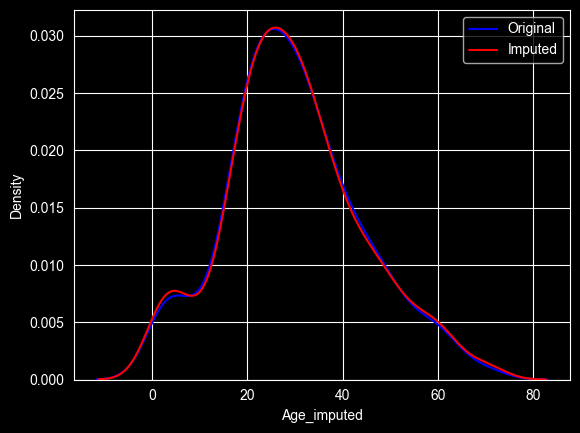

In [55]:
sns.distplot(X_train['Age'], hist=False,label='Original', color='blue')
sns.distplot(X_train['Age_imputed'], hist=False,label='Imputed', color='red')
plt.legend()
plt.show()

In [56]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  211.92972505708843


In [57]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,58.542569
Age,71.512440,204.349513,204.349513
Age_imputed,58.542569,204.349513,211.929725


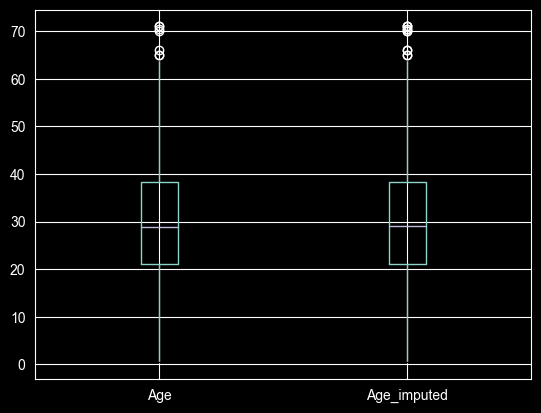

In [58]:
X_train[['Age','Age_imputed']].boxplot()
plt.show()

In [59]:
# Problem on a random imputation like on a production for a same input model gives the different output the solution is like if the fare is same then the output will also be same
# smapled_value = X_train['Age'].dropna().sample(1,random_state=int(observation['Fare']))

In [60]:
data = pd.read_csv('house-train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [61]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [62]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [63]:
X = data
y = data['SalePrice']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [69]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [71]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
657,Gd,TA,149000,TA,Gd
617,NaN,TA,105500,TA,NaN
1285,Gd,TA,132500,TA,Gd
329,NaN,Fa,78000,Fa,NaN
977,NaN,TA,199900,TA,NaN


In [72]:
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = \
    X_train['GarageQual'].dropna().sample(X_train['GarageQual_imputed'].isnull().sum()).values

X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = \
    X_train['GarageQual'].dropna().sample(X_test['GarageQual_imputed'].isnull().sum()).values

X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = \
    X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu_imputed'].isnull().sum()).values

X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = \
    X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu_imputed'].isnull().sum()).values

In [74]:
temp = pd.concat(
    [
    X_train['GarageQual_imputed'].value_counts()/len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputed'].value_counts()/len(X_train)
], axis=1)

temp.columns = ['original', 'imputed']

In [75]:
temp

,original,imputed
GarageQual_imputed,,
TA,1.004533,0.948630
Fa,0.041704,0.039384
Gd,0.009973,0.009418
Po,0.001813,0.001712
Ex,0.000907,0.000856


In [76]:
temp = pd.concat(
    [
    X_train['FireplaceQu_imputed'].value_counts()/len(X_train['FireplaceQu'].dropna()),
        X_train['FireplaceQu_imputed'].value_counts()/len(X_train)
], axis=1)

temp.columns = ['original', 'imputed']

In [77]:
temp

,original,imputed
FireplaceQu_imputed,,
Gd,0.942717,0.493151
TA,0.792144,0.414384
Fa,0.078560,0.041096
Po,0.055646,0.029110
Ex,0.042553,0.022260


C:\Users\MY PC\AppData\Local\Temp\ipykernel_23152\1625265867.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu']==category]['SalePrice'],hist=False,label=category)
C:\Users\MY PC\AppData\Local\Temp\ipykernel_23152\1625265867.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6

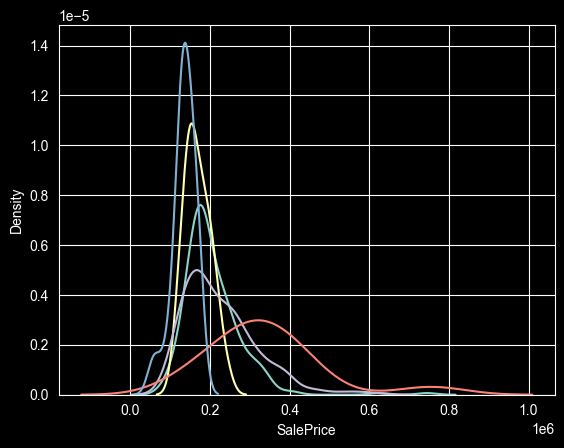

In [79]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu']==category]['SalePrice'],hist=False,label=category)

plt.show()

C:\Users\MY PC\AppData\Local\Temp\ipykernel_23152\4004433589.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed']==category]['SalePrice'],hist=False,label=category)
C:\Users\MY PC\AppData\Local\Temp\ipykernel_23152\4004433589.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed29

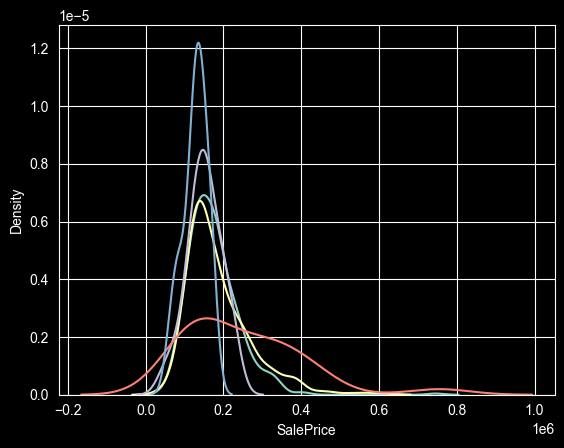

In [80]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed']==category]['SalePrice'],hist=False,label=category)

plt.show()